## **Import necessary libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

In [3]:
pip install transformers datasets torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
pip install --upgrade torch transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 84.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.50.3
    Uninstalling transformers-4.50.3:
      Successfully uninstalled transformers-4.50.3


In [5]:
pip install --upgrade transformers


In [6]:
pip install accelerate -U


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.5.2
    Uninstalling accelerate-1.5.2:
      Successfully uninstalled accelerate-1.5.2


## Data Preprocessing

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products


In [8]:
import os

# List all files in the directory
for file in os.listdir(path):
    print(file)

Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
1429_1.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv


In [9]:
#Load datasets
df1 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
df2 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))

In [10]:
#Datasets Shape Check
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

df1 shape: (5000, 24)
df2 shape: (28332, 24)


In [11]:
# Check columns of each dataset
print("Columns in df1:", df1.columns)
print("Columns in df2:", df2.columns)

Columns in df1: Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')
Columns in df2: Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')


In [12]:
df1.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.dateSeen,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-09-18T00:00:00Z,2017...",False,NaN,0,3,http://reviews.bestbuy.com/3545/5442403/review...,I thought it would be as big as small paper bu...,Too small,llyyue,https://www.newegg.com/Product/Product.aspx%25...
1,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-07-07T00:00:00Z,2017...",True,NaN,0,5,http://reviews.bestbuy.com/3545/5442403/review...,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,https://www.newegg.com/Product/Product.aspx%25...
2,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,4,https://reviews.bestbuy.com/3545/5442403/revie...,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,https://www.newegg.com/Product/Product.aspx%25...
3,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-10-09T00:00:00Z,True,177283626.0,3,5,https://redsky.target.com/groot-domain-api/v1/...,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry,https://www.newegg.com/Product/Product.aspx%25...
4,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,5,https://reviews.bestbuy.com/3545/5442403/revie...,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack,https://www.newegg.com/Product/Product.aspx%25...


In [13]:
df2.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [14]:
#Get the frequency of each review rating
df1['reviews.rating'].value_counts()

,count
reviews.rating,
5,3478
4,1208
3,197
1,63
2,54


In [15]:
df2['reviews.rating'].value_counts()

,count
reviews.rating,
5,19897
4,5648
3,1206
1,965
2,616


In [16]:
# Merge datasets df1 and df2
df = pd.concat([df1, df2], ignore_index=True)

In [17]:
# Missing Value Check
df.isnull().sum()

,0
id,0
dateAdded,0
dateUpdated,0
name,0
asins,0
brand,0
categories,0
primaryCategories,0
imageURLs,0
keys,0


In [18]:
df.columns

Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateAdded',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs',
       'reviews.didPurchase'],
      dtype='object')

In [20]:
# Select relevant columns
df = df[['reviews.text', 'reviews.rating','reviews.title']]

In [21]:
df.head()

,reviews.text,reviews.rating,reviews.title
0,I thought it would be as big as small paper bu...,3,Too small
1,This kindle is light and easy to use especiall...,5,Great light reader. Easy to use at the beach
2,Didnt know how much i'd use a kindle so went f...,4,Great for the price
3,I am 100 happy with my purchase. I caught it o...,5,A Great Buy
4,Solid entry level Kindle. Great for kids. Gift...,5,Solid entry-level Kindle. Great for kids


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33332 entries, 0 to 33331
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   reviews.text    33332 non-null  object
 1   reviews.rating  33332 non-null  int64 
 2   reviews.title   33319 non-null  object
dtypes: int64(1), object(2)
memory usage: 781.3+ KB


In [23]:
df.isnull().sum()

,0
reviews.text,0
reviews.rating,0
reviews.title,13


In [24]:
df.duplicated().sum()

np.int64(13261)

In [25]:
duplicates = df[df.duplicated()]
print(duplicates.head())


                                          reviews.text  reviews.rating  \
748  Love this. Just replaced my old echo with this...               5   
750  Alexa Show is really well put together. The ma...               5   
755  The Echo Dot is a great personal assistant, an...               5   
756  Addition to my system...love talking and seein...               5   
757  We love Alexa! Love being able to watch news b...               5   

                              reviews.title  
748                              Love alexa  
750                    Alexa is very useful  
755  Echo Dot is a great personal assistant  
756                              Love Alexa  
757                                 Awesome  


In [26]:
df = df.drop_duplicates()

In [27]:
# Drop rows with missing titles
df.dropna(subset=['reviews.title'], inplace=True)

In [28]:
df.isnull().sum()

,0
reviews.text,0
reviews.rating,0
reviews.title,0


In [29]:
df.shape

(20060, 3)

In [30]:
# Map star ratings to sentiment categories (Negative, Neutral, Positive)
def map_sentiment(rating):
    if rating <= 2.0:
        return "Negative"
    elif rating == 3.0:
        return "Neutral"
    else:
        return "Positive"

In [31]:
# Apply sentiment mapping to ratings column
df.loc[:,'reviews.rating'] = df['reviews.rating'].apply(map_sentiment)

<ipython-input-31-c85360c54ba9>:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Neutral' 'Positive' 'Positive' ... 'Positive' 'Positive' 'Positive']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:,'reviews.rating'] = df['reviews.rating'].apply(map_sentiment)


In [32]:
# Check the distribution of sentiment labels in 'reviews.rating'
df['reviews.rating'].value_counts()

,count
reviews.rating,
Positive,17960
Negative,1224
Neutral,876


reviews.rating
Positive    17960
Negative     1224
Neutral       876
Name: count, dtype: int64


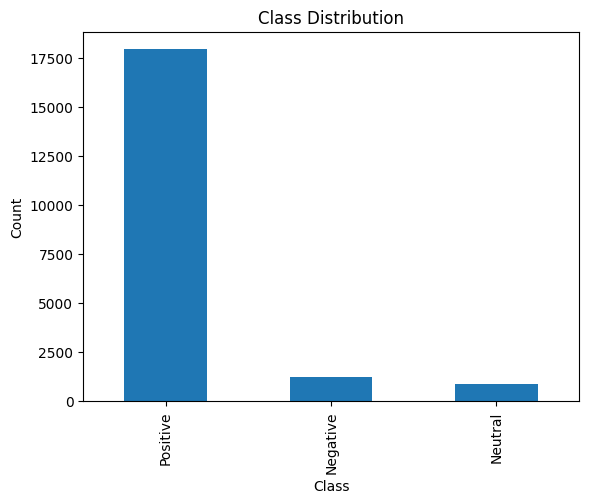

In [33]:
# Plot the distribution
class_counts = df['reviews.rating'].value_counts()
print(class_counts)

# Visualize
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [34]:
# Downsample Positive reviews to balance the dataset
target_category = 'Positive'
n_rows = 3500

# Downsample Positive reviews
positive_sampled = df[df['reviews.rating'] == target_category].sample(n=n_rows, random_state=42)

# Keep all other rows as-is
others = df[df['reviews.rating'] != target_category]

# Combine into a new balanced DataFrame
df = pd.concat([positive_sampled, others], ignore_index=True)

In [35]:
df['reviews.rating'].value_counts()

,count
reviews.rating,
Positive,3500
Negative,1224
Neutral,876


In [36]:
# Combine title and text to form complete review content
df.loc[:,'reviews.text'] = df['reviews.title'] + " " + df['reviews.text']

In [37]:
# Drop the 'reviews.title' column after merging
df.drop('reviews.title', axis=1, inplace=True)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5600 entries, 0 to 5599
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   reviews.text    5600 non-null   object
 1   reviews.rating  5600 non-null   object
dtypes: object(2)
memory usage: 87.6+ KB


In [39]:
df.isnull().sum()

,0
reviews.text,0
reviews.rating,0


In [40]:
# Display the first review's text and rating
df['reviews.text'].iloc[0]+": "+df['reviews.rating'].iloc[0]

'Five Stars Worked fine: Positive'

[Text(0.5, 1.0, 'Distribution of Reviews Ratings'),
 Text(0.5, 0, 'Rating'),
 Text(0, 0.5, 'Count')]

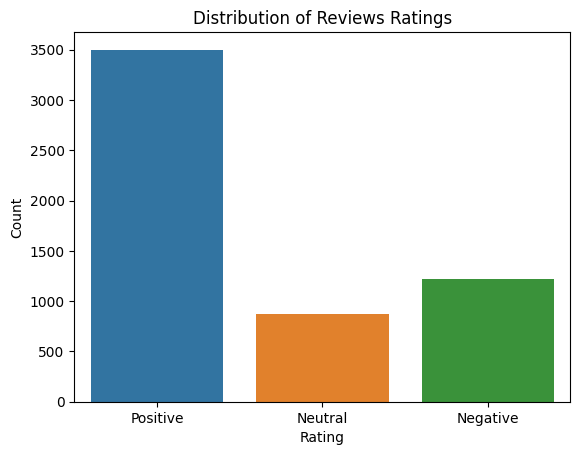

In [42]:
# Visualize the distribution of review ratings
sns.countplot(x = 'reviews.rating',
              data = df,
              hue='reviews.rating',
              legend=False).set(title='Distribution of Reviews Ratings', xlabel='Rating', ylabel='Count')

## B

In [43]:
# Count the frequency of each review rating using Counter

labels = df['reviews.rating']
print(Counter(labels))

Counter({'Positive': 3500, 'Negative': 1224, 'Neutral': 876})


In [44]:
# Compute class weights to handle imbalanced classes

# Get the unique classes
classes = np.unique(labels)

# Compute weights
weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)
print(weights)

[1.52505447 2.13089802 0.53333333]


## Load the Pre-trained Model

In [45]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from datasets import Dataset
import torch

In [46]:
# Load tokenizer and model
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=3)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [47]:
data = df[['reviews.text', 'reviews.rating']]

#Map sentiment labels
data['reviews.rating'] = data['reviews.rating'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})

# Convert the DataFrame to a dataset
dataset = Dataset.from_pandas(data)

In [48]:
# Tokenize the dataset
# Define tokenization function for the 'reviews.text' column
def tokenize_function(examples):
    return tokenizer(examples['reviews.text'], padding="max_length", truncation=True)

# Tokenize the dataset using the tokenizer and apply padding and truncation
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# Rename 'reviews.rating' to 'labels'
tokenized_dataset = tokenized_dataset.rename_column("reviews.rating", "labels")

# Split the tokenized dataset into training and test sets (80/20)
tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.2)

Map:   0%|          | 0/5600 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['reviews.text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 5143
    })
    test: Dataset({
        features: ['reviews.text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 1286
    })
})

In [49]:
# Separate train and test datasets
train =tokenized_dataset['train']
test =tokenized_dataset['test']

In [50]:
from transformers import Trainer
from torch import nn

# Define CustomTrainer class that extends Hugging Face Trainer
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Define the custom loss function with class weights
        loss_fct = nn.CrossEntropyLoss(weight=torch.tensor([1.31472393, 1.64973056, 0.61228571], device=model.device))
        # Compute custom loss
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [51]:
#Create a directory to contain the Model
import os
working_dir = './'

output_directory = os.path.join(working_dir, "output_directory")

In [52]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=output_directory,
    save_strategy="epoch",  # Save checkpoint after each epoch
    learning_rate=2e-5,     # Set learning rate
    num_train_epochs=3,     # Number of epochs
    per_device_train_batch_size=8,  # Training batch size
    per_device_eval_batch_size=8,   # Evaluation batch size
    logging_dir='./logs',    # Directory for logs
    logging_steps=10         # Log every 10 steps
)

In [53]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

# Define compute_metrics function to calculate accuracy and F1 score
def compute_metrics(logits_and_labels):
  logits, labels = logits_and_labels
  predictions = np.argmax(logits, axis=-1)
  acc = np.mean(predictions == labels)
  f1 = f1_score(labels, predictions, average = 'micro')
  return {'accuracy': acc, 'f1_score': f1}

In [54]:
from transformers import Trainer

# Initialize CustomTrainer with model, training arguments, datasets, and metrics
trainer = CustomTrainer(model,
                        training_args,
                        train_dataset = train,
                        eval_dataset = test,
                        tokenizer=tokenizer,
                        compute_metrics=compute_metrics)

<ipython-input-54-2ebf6787b00e>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  trainer = CustomTrainer(model,


In [55]:
# Start the training
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lamaalwuth (lamaalwuth-na) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
10,1.102300
20,1.096700
30,1.038600
40,0.977000
50,0.743200
60,0.691100
70,0.712800
80,0.694200
90,0.615700
100,0.575100


TrainOutput(global_step=1680, training_loss=0.45858593487313815, metrics={'train_runtime': 319.4335, 'train_samples_per_second': 42.074, 'train_steps_per_second': 5.259, 'total_flos': 3536244334264320.0, 'train_loss': 0.45858593487313815, 'epoch': 3.0})

In [60]:
! ls output_directory

checkpoint-1120  checkpoint-1680  checkpoint-560


In [57]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

# Run evaluation on the test dataset
preds_output = trainer.predict(test)

# Get true labels (y_true) and predicted labels (y_pred)
y_true = preds_output.label_ids
y_pred = preds_output.predictions.argmax(axis=-1)

# Check accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Model achieved an accuracy of {accuracy * 100:.2f}%  on the test dataset.")

Model achieved an accuracy of 89.64%  on the test dataset.


In [58]:
# Calculate precision recall, and F1-score for each class
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred)
for i, label in enumerate(["Negative","Neutral", "Positive"]):
    print(f"Class {label}:")
    print(f"  Precision: {precision[i] * 100:.2f}%")
    print(f"  Recall: {recall[i] * 100:.2f}%")
    print(f"  F1-Score: {f1[i] * 100:.2f}%")
    print("")

Class Negative:
  Precision: 86.94%
  Recall: 89.96%
  F1-Score: 88.43%

Class Neutral:
  Precision: 67.38%
  Recall: 61.29%
  F1-Score: 64.19%

Class Positive:
  Precision: 95.08%
  Recall: 95.75%
  F1-Score: 95.41%



Confusion Matrix:
[[233  23   3]
 [ 28  95  32]
 [  7  23 676]]


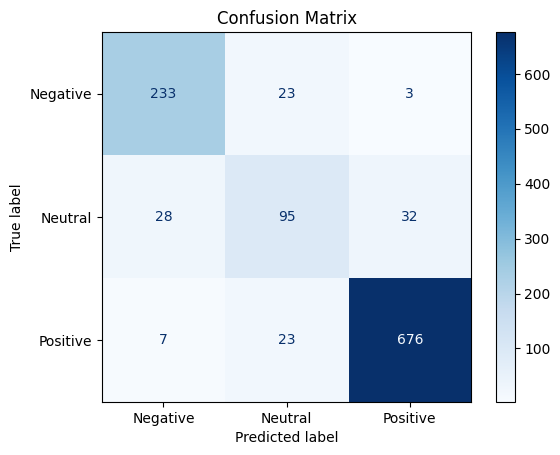

In [59]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative","Neutral", "Positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## Apply Your Model to All Reviews:

In [61]:
# Convert your saved model into a pipeline for easy prediction
from transformers import pipeline

# Load your trained model
sentiment_pipeline = pipeline('text-classification', model='output_directory/checkpoint-560')

Device set to use cuda:0


In [62]:
# Apply to all reviews (original dataset before downsampling)
df1 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
df2 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))
original_df = pd.concat([df1, df2], ignore_index=True)
original_df['reviews.text'] = original_df['reviews.title'].fillna('') + " " + original_df['reviews.text'].fillna('')

In [ ]:
# Process in batches to avoid memory issues
all_predictions = []
batch_size = 32

for i in range(0, len(original_df), batch_size):
    batch_texts = original_df['reviews.text'][i:i+batch_size].tolist()
    batch_results = sentiment_pipeline(batch_texts)

    # Extract the predicted labels
    batch_predictions = [result['label'] for result in batch_results]
    all_predictions.extend(batch_predictions)

# Map numeric labels back to text
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
original_df['sentiment'] = [label_map[int(pred)] for pred in all_predictions]

# Save the classified reviews
original_df[['id', 'name', 'reviews.text', 'reviews.rating', 'sentiment']].to_csv('classified_reviews.csv', index=False)

## **Save the model**

In [56]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [64]:
model.save_pretrained("final_modelv3")

In [65]:
trainer.save_model("final_modelv3")
tokenizer.save_pretrained("final_modelv3")

('final_modelv3/tokenizer_config.json',
 'final_modelv3/special_tokens_map.json',
 'final_modelv3/vocab.json',
 'final_modelv3/merges.txt',
 'final_modelv3/added_tokens.json',
 'final_modelv3/tokenizer.json')

In [66]:
!cp -r final_modelv3 /content/drive/MyDrive/


In [67]:
# Save both model and tokenizer in PyTorch format
model.save_pretrained("final_modelv3py", safe_serialization=False)
tokenizer.save_pretrained("final_modelv3py")

('final_modelv3py/tokenizer_config.json',
 'final_modelv3py/special_tokens_map.json',
 'final_modelv3py/vocab.json',
 'final_modelv3py/merges.txt',
 'final_modelv3py/added_tokens.json',
 'final_modelv3py/tokenizer.json')

In [68]:
!cp -r final_modelv3py /content/drive/MyDrive/
